In [2]:
import polars as pl
pl.Config.set_tbl_rows(-1)       # -1 means "show all rows"
pl.Config.set_tbl_cols(-1)       # -1 means "show all columns"
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [8]:
import polars as pl

# 1. Scan lazily
lazy_df = pl.scan_parquet("..//output2//parquets//IDS2018_cleaned_v2.parquet")
print("Plan loaded. Analyzing label distribution...")

# 2. Get counts (Using .len() to avoid the DeprecationWarning)
label_counts = lazy_df.select("Label").group_by("Label").len().collect()
print(label_counts)

train_frames = []
test_frames = []
val_frames = []

# 3. Stratified Split Logic
for label in label_counts["Label"]:
    # Filter for the class (Lazy)
    shuffled_lazy = lazy_df.filter(pl.col("Label") == label)
    
    # We SHUFFLE the class lazily first. 
    # This ensures that when we slice it, we get a random distribution.
    
    
    # Get the total count for this label to calculate slice offsets
    total_count = label_counts.filter(pl.col("Label") == label)["len"][0]
    
    # Calculate sizes for 70/20/10 split
    train_size = int(total_count * 0.7)
    test_size = int(total_count * 0.2)
    # Val size is the remainder
    
    # Use .slice(offset, length) - This is LAZY and RAM-friendly
    # Slice 1: Start at 0, take 70%
    train_frames.append(shuffled_lazy.slice(0, train_size))
    
    # Slice 2: Start after train, take 20%
    test_frames.append(shuffled_lazy.slice(train_size, test_size))
    
    # Slice 3: Start after test, take the rest
    val_frames.append(shuffled_lazy.slice(train_size + test_size, None))
    
    print(f"Added lazy slices for: {label}")

# 4. The SINK (The only part that actually processes the data)
print("Sinking to disk... This avoids loading the 2GB into RAM.")

pl.concat(train_frames).sink_parquet("..//output2//parquets//train//1_train_data.parquet")
pl.concat(test_frames).sink_parquet("..//output2//parquets//test//1_test_data.parquet")
pl.concat(val_frames).sink_parquet("..//output2//parquets//val//1_val_data.parquet")

print("Stratified split complete! 3 files generated: train, test, val.")

Plan loaded. Analyzing label distribution...
shape: (14, 2)
┌──────────────────────────┬─────────┐
│ Label                    ┆ len     │
│ ---                      ┆ ---     │
│ str                      ┆ u32     │
╞══════════════════════════╪═════════╡
│ Brute Force -XSS         ┆ 230     │
│ SQL Injection            ┆ 87      │
│ DoS attacks-GoldenEye    ┆ 41508   │
│ DDOS attack-HOIC         ┆ 686012  │
│ Brute Force -Web         ┆ 611     │
│ SSH-Bruteforce           ┆ 187589  │
│ DDOS attack-LOIC-UDP     ┆ 1730    │
│ DoS attacks-Slowloris    ┆ 10990   │
│ FTP-BruteForce           ┆ 193360  │
│ Label                    ┆ 59      │
│ Benign                   ┆ 6112151 │
│ Bot                      ┆ 286191  │
│ DoS attacks-Hulk         ┆ 461912  │
│ DoS attacks-SlowHTTPTest ┆ 139890  │
└──────────────────────────┴─────────┘
Added lazy slices for: Brute Force -XSS
Added lazy slices for: SQL Injection
Added lazy slices for: DoS attacks-GoldenEye
Added lazy slices for: DDOS attack-HOI

In [9]:
import polars as pl

# 1. Scan the raw data
lf = pl.scan_parquet("..//output2//parquets//train//1_train_data.parquet")

# 2. Define the cleaning plan
exclude = ['Timestamp', 'Label']
numeric_cols = [col for col in lf.columns if col not in exclude]

# 3. Apply cleaning AND the sink in one go
(
    lf.with_columns([
        pl.col(numeric_cols).cast(pl.Float64, strict=False)
    ])
    .sink_parquet("..//output2//parquets//train//2_train_data_str_handled.parquet")
)

print("✅ Cleaned without any manual batching errors!")

C:\Users\akhiz\AppData\Local\Temp\ipykernel_7064\3733515077.py:8: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  numeric_cols = [col for col in lf.columns if col not in exclude]


✅ Cleaned without any manual batching errors!


In [10]:
import polars as pl
import os
import shutil

input_path = "..//output2//parquets//train//2_train_data_str_handled.parquet"
output_path = "..//output2//parquets//train//3_train_data_deduplicated.parquet"
bucket_dir = "dup_check_buckets"
os.makedirs(bucket_dir, exist_ok=True)

print("🚀 Step 1: Partitioning data using Row-Level Hashing...")
lf = pl.scan_parquet(input_path)

# THE FIX: Use pl.struct(pl.all()).hash() to get ONE hash per row
for i in range(10):
    (
        lf.filter(
            pl.struct(pl.all()).hash(seed=42).mod(10) == i
        )
        .sink_parquet(f"{bucket_dir}/bucket_{i}.parquet")
    )
    print(f"✅ Bucket {i} written to disk.")

    
print("\n🧹 Step 2: Removing duplicates within buckets...")
for i in range(10):
    bucket_file = f"{bucket_dir}/bucket_{i}.parquet"
    if not os.path.exists(bucket_file): continue
    
    # Read the bucket and apply .unique()
    # Since identical rows are in the same bucket, this catches all duplicates
    (
        pl.read_parquet(bucket_file)
        .unique() 
        .write_parquet(f"{bucket_dir}/cleaned_bucket_{i}.parquet")
    )
    
    os.remove(bucket_file)
    print(f"✨ Bucket {i} cleaned.")

# 3. Final Merge
print("\n🔗 Step 3: Merging buckets into final gold dataset...")
pl.scan_parquet(f"{bucket_dir}/cleaned_bucket_*.parquet").sink_parquet(output_path)

# 4. Final Verification
initial_rows = pl.scan_parquet(input_path).select(pl.len()).collect().item()
final_rows = pl.scan_parquet(output_path).select(pl.len()).collect().item()
removed = initial_rows - final_rows
retention = (final_rows / initial_rows) * 100

print("\n" + "="*80)
print("✅ GLOBAL DEDUPLICATION COMPLETE")
print("="*80)
print(f"📊 Initial rows:  {initial_rows:,}")
print(f"📊 Final rows:    {final_rows:,}")
print(f"📉 Rows removed:  {removed:,}")
print(f"📈 Retention:     {retention:.2f}%")

# Cleanup
shutil.rmtree(bucket_dir)


🚀 Step 1: Partitioning data using Row-Level Hashing...
✅ Bucket 0 written to disk.
✅ Bucket 1 written to disk.
✅ Bucket 2 written to disk.
✅ Bucket 3 written to disk.
✅ Bucket 4 written to disk.
✅ Bucket 5 written to disk.
✅ Bucket 6 written to disk.
✅ Bucket 7 written to disk.
✅ Bucket 8 written to disk.
✅ Bucket 9 written to disk.

🧹 Step 2: Removing duplicates within buckets...
✨ Bucket 0 cleaned.
✨ Bucket 1 cleaned.
✨ Bucket 2 cleaned.
✨ Bucket 3 cleaned.
✨ Bucket 4 cleaned.
✨ Bucket 5 cleaned.
✨ Bucket 6 cleaned.
✨ Bucket 7 cleaned.
✨ Bucket 8 cleaned.
✨ Bucket 9 cleaned.

🔗 Step 3: Merging buckets into final gold dataset...

✅ GLOBAL DEDUPLICATION COMPLETE
📊 Initial rows:  5,685,618
📊 Final rows:    5,416,440
📉 Rows removed:  269,178
📈 Retention:     95.27%


In [11]:
import polars as pl

# 1. SETUP & SCAN
input_path = "..//output2//parquets//train//3_train_data_deduplicated.parquet"
output_path = "..//output2//parquets//train//4_train_data_cleaned_invalid_inputs.parquet"

print("=" * 80)
print("🧹 POLARS CLEANING - INVALID FLOW REMOVAL")
print("=" * 80)

# Scan the data (Lazy - no RAM used yet)
lf = pl.scan_parquet(input_path)

# Initial State
initial_rows = lf.select(pl.len()).collect().item()
print(f"\n📊 Initial Dataset:")
print(f"    Total rows: {initial_rows:,}")
print(f"    Total columns: {len(lf.columns)}")

# =============================================================
# STEP 1 & 2: REMOVE DUPLICATES & INVALID FLOWS
# =============================================================
# We handle the 'Invalid Flow' check: (~(FwdPkts=0 AND BwdPkts=0 AND Duration=0))
# .fill_null(0) ensures we don't accidentally drop rows with valid Nulls
cleaned_lf = (
    lf
    .filter(
        ~(
            (pl.col("Tot Fwd Pkts").fill_null(0) == 0) & 
            (pl.col("Tot Bwd Pkts").fill_null(0) == 0) & 
            (pl.col("Flow Duration").fill_null(0) == 0)
        )
    )
    # STEP 3: Remove completely empty/corrupt lines (dropna how='all')
    .filter(~pl.all_horizontal(pl.all().is_null()))
)

# =============================================================
# STEP 4: EXECUTION & REPORTING
# =============================================================
# We 'sink' the data to run the plan without crashing the kernel
print(f"\n🔍 Processing filters and saving to disk...")
cleaned_lf.sink_parquet(output_path)

# Scan the newly created file for final stats
final_lf = pl.scan_parquet(output_path)
final_rows = final_lf.select(pl.len()).collect().item()
removed = initial_rows - final_rows
retention = (final_rows / initial_rows) * 100

print("\n" + "=" * 80)
print("✅ CLEANING COMPLETE")
print("=" * 80)
print(f"📊 Final Dataset:")
print(f"    Total rows: {final_rows:,}")
print(f"    Rows removed: {removed:,}")
print(f"    Retention rate: {retention:.2f}%")

# =============================================================
# STEP 5: LABEL DISTRIBUTION
# =============================================================
if "Label" in final_lf.columns:
    print(f"\n🎯 Label Distribution After Cleaning:")
    # We group by label, count, and calculate percentage
    dist = (
        final_lf.group_by("Label")
        .len()
        .with_columns(
            (pl.col("len") / final_rows * 100).round(2).alias("%")
        )
        .sort("len", descending=True)
        .collect()
    )
    
    # Configure Polars to show all labels
    with pl.Config(tbl_rows=-1):
        print(dist)

print("\n" + "=" * 80)
print(f"💾 Cleaned dataset stored in '{output_path}'")
print("=" * 80)

🧹 POLARS CLEANING - INVALID FLOW REMOVAL

📊 Initial Dataset:
    Total rows: 5,416,440
    Total columns: 80

🔍 Processing filters and saving to disk...


C:\Users\akhiz\AppData\Local\Temp\ipykernel_7064\3562495714.py:18: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(f"    Total columns: {len(lf.columns)}")



✅ CLEANING COMPLETE
📊 Final Dataset:
    Total rows: 5,416,439
    Rows removed: 1
    Retention rate: 100.00%

🎯 Label Distribution After Cleaning:


C:\Users\akhiz\AppData\Local\Temp\ipykernel_7064\3562495714.py:62: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "Label" in final_lf.columns:


shape: (13, 3)
┌──────────────────────────┬─────────┬───────┐
│ Label                    ┆ len     ┆ %     │
│ ---                      ┆ ---     ┆ ---   │
│ str                      ┆ u32     ┆ f64   │
╞══════════════════════════╪═════════╪═══════╡
│ Benign                   ┆ 4270487 ┆ 78.84 │
│ DDOS attack-HOIC         ┆ 473210  ┆ 8.74  │
│ DoS attacks-Hulk         ┆ 302033  ┆ 5.58  │
│ Bot                      ┆ 198386  ┆ 3.66  │
│ SSH-Bruteforce           ┆ 87471   ┆ 1.61  │
│ DoS attacks-GoldenEye    ┆ 29038   ┆ 0.54  │
│ FTP-BruteForce           ┆ 27496   ┆ 0.51  │
│ DoS attacks-SlowHTTPTest ┆ 19462   ┆ 0.36  │
│ DoS attacks-Slowloris    ┆ 6997    ┆ 0.13  │
│ DDOS attack-LOIC-UDP     ┆ 1211    ┆ 0.02  │
│ Brute Force -Web         ┆ 427     ┆ 0.01  │
│ Brute Force -XSS         ┆ 161     ┆ 0.0   │
│ SQL Injection            ┆ 60      ┆ 0.0   │
└──────────────────────────┴─────────┴───────┘

💾 Cleaned dataset stored in '..//output2//parquets//train//4_train_data_cleaned_invalid_inp

In [12]:
# lets take a small sample to test if there is relation btw certain columns 
# 'Pkt Len Mean', 'Pkt Len Var', 'Pkt Len Std'
# 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std','Fwd Seg Size Avg',
# 'Bwd Pkt Len Mean','Bwd Pkt Len Std','Bwd Seg Size Avg'
import polars as pl
input_path = "..//output2//parquets//train//4_train_data_cleaned_invalid_inputs.parquet"

lazy_df = pl.scan_parquet(input_path)
# Fix the seed so results are repeatable across runs


In [13]:
import polars as pl
from scipy import stats

# Assuming 'path' and 'cond' are defined earlier in your script
# input_path = f"{path}/2_{cond}_data_str_handled.parquet" 

print("="*60)
print("AUTOMATED FEATURE CORRELATION & INFERENCE")
print("="*60)

# 1. Create the lazy graph and filter for valid data
lazy_df = pl.scan_parquet(input_path)

print("Collecting data subset into memory...")
df_subset = (
    lazy_df
    .select(['Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Fwd Seg Size Avg'])
    .drop_nulls()
    .collect()
)

# Extract NumPy arrays
mean_arr = df_subset['Fwd Pkt Len Mean'].to_numpy()
var_arr = df_subset['Fwd Seg Size Avg'].to_numpy()
std_arr = df_subset['Fwd Pkt Len Std'].to_numpy()

# 2. The Inference Engine
def evaluate_and_infer(name_a, name_b, arr_a, arr_b):
    corr, p_value = stats.pearsonr(arr_a, arr_b)
    
    print(f"\nTest: [{name_a}] vs [{name_b}]")
    print(f"  Coefficient (r): {corr:.4f}")
    print(f"  p-value:         {p_value:.4e}")
    
    # Automated Inference Logic
    print("  -> INFERENCE:    ", end="")
    
    if p_value >= 0.05:
        print("[SAFE] No statistically significant correlation found.")
        return
        
    abs_corr = abs(corr)
    if abs_corr >= 0.95:
        print("[CRITICAL] Extremely high correlation. Mathematically redundant. ACTION: Drop one.")
    elif abs_corr >= 0.75:
        print("[WARNING] Strong correlation. Safe to keep, but monitors for overfitting.")
    elif abs_corr >= 0.30:
        print("[SAFE] Moderate correlation. Both features provide unique value.")
    else:
        print("[SAFE] Weak correlation. Safe to keep both.")

# 3. Run the tests
print("\n--- Formal Statistical Tests ---")
evaluate_and_infer('Fwd Seg Size Avg', 'Fwd Pkt Len Std', var_arr, std_arr)
evaluate_and_infer('Fwd Pkt Len Mean', 'Fwd Pkt Len Std', mean_arr, std_arr)
evaluate_and_infer('Fwd Pkt Len Mean', 'Fwd Seg Size Avg', mean_arr, var_arr)

print("\n" + "="*60)

AUTOMATED FEATURE CORRELATION & INFERENCE

--- Formal Statistical Tests ---

Test: [Fwd Seg Size Avg] vs [Fwd Pkt Len Std]
  Coefficient (r): 0.9170
  p-value:         0.0000e+00
  -> INFERENCE:    [WARNING] Strong correlation. Safe to keep, but monitors for overfitting.

Test: [Fwd Pkt Len Mean] vs [Fwd Pkt Len Std]
  Coefficient (r): 0.9170
  p-value:         0.0000e+00
  -> INFERENCE:    [WARNING] Strong correlation. Safe to keep, but monitors for overfitting.

Test: [Fwd Pkt Len Mean] vs [Fwd Seg Size Avg]
  Coefficient (r): 1.0000
  p-value:         0.0000e+00
  -> INFERENCE:    [CRITICAL] Extremely high correlation. Mathematically redundant. ACTION: Drop one.



In [14]:
import polars as pl

# Define paths
input_path = "..//output2//parquets//train//4_train_data_cleaned_invalid_inputs.parquet"
output_path = "..//output2//parquets//train//5_train_redundent_removed.parquet"

print("="*60)
print("LAZY FEATURE ENGINEERING (COEFFICIENT OF VARIATION)")
print("="*60)

# 1. Create the Lazy Computation Graph
lazy_df = pl.scan_parquet(input_path)

# 2. Mathematically combine the features
# We add 1e-5 (0.00001) to the denominator to mathematically prevent "Division by Zero" crashes
lazy_df = lazy_df.with_columns([
    (pl.col('Pkt Len Std') / (pl.col('Pkt Len Mean') + 1e-5)).alias('Pkt_Len_CV'),
    (pl.col('Fwd Pkt Len Std') / (pl.col('Fwd Pkt Len Mean') + 1e-5)).alias('Fwd_Pkt_Len_CV'),
    (pl.col('Bwd Pkt Len Std') / (pl.col('Bwd Pkt Len Mean') + 1e-5)).alias('Bwd_Pkt_Len_CV')
])

# 3. Drop the redundant raw columns
# We keep the 'Mean' as our anchor, keep our new 'CV' column, and drop the rest.
columns_to_drop = [
    'Pkt Len Var', 'Pkt Len Std', 
    'Fwd Pkt Len Std', 'Fwd Seg Size Avg', 
    'Bwd Pkt Len Std', 'Bwd Seg Size Avg'
]

lazy_df = lazy_df.drop(columns_to_drop)

# 4. Stream the results to disk
print("Calculating new features and streaming to disk...")
lazy_df.sink_parquet(output_path)

print(f"Data successfully engineered and saved to: {output_path}")

LAZY FEATURE ENGINEERING (COEFFICIENT OF VARIATION)
Calculating new features and streaming to disk...
Data successfully engineered and saved to: ..//output2//parquets//train//5_train_redundent_removed.parquet


In [15]:
import polars as pl

# --- CONFIGURATION ---
input_path = "..//output2//parquets//train//5_train_redundent_removed.parquet"
output_path = "..//output2//parquets//train//6_train_data_optimized.parquet"

print("=" * 80)
print("POLARS: STREAMING FEATURE SELECTION & OPTIMIZATION")
print("=" * 80)

# 1. Scan the data to get available columns (Lazy, no RAM used)
lf = pl.scan_parquet(input_path)
available_columns = lf.columns

# =============================================================
# STEP 1: KEEP ONLY IMPORTANT FEATURES
# =============================================================
important_features = [
    'Timestamp','Bwd_Pkt_Len_CV','Fwd_Pkt_Len_CV','Pkt_Len_CV', 'Src Port', 'Dst Port', 'Protocol',
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s',
    'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Mean', 'Pkt Len Var', 'Pkt Len Std',
    'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std',
    'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Active Mean', 'Idle Mean', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Mean', 'Bwd IAT Mean', 'Down/Up Ratio', 'Label'
]

# Ensure we only try to keep columns that actually exist in the file
keep_cols = [c for c in important_features if c in available_columns]
print(f"Selecting {len(keep_cols)} key features (Discarding the rest)")

# Identify categorical candidates dynamically
cat_candidates = [c for c in ['Protocol', 'Label'] if c in keep_cols]

# =============================================================
# STEP 2: BUILD THE OPTIMIZATION PLAN
# =============================================================
# THE FIX: Chain with_columns sequentially to avoid parallel assignment conflicts
optimized_lf = (
    lf.select(keep_cols)
    # Phase A: Downcast all numeric columns
    .with_columns([
        pl.col(pl.Float64).cast(pl.Float32),
        pl.col(pl.Int64).cast(pl.Int32),
    ])
    # Phase B: Convert specific columns to Categorical (Overwrites Phase A if needed)
    .with_columns([
        pl.col(cat_candidates).cast(pl.String).cast(pl.Categorical),
    ])
)

# YA DATA MANUALLY ATTACKED
# SO HIGH CHANCES KAH IP ADDRESS REPEAT HON AOR WO ACTUALLY KHUCH REPRESENT NA KRAIN


# =============================================================
# STEP 3: EXECUTE & SINK
# =============================================================
print("Processing and saving optimized dataset...")
optimized_lf.sink_parquet(output_path)

# =============================================================
# STEP 4: FINAL MEMORY REPORT
# =============================================================
df_final = pl.read_parquet(output_path)
mem_mb = df_final.estimated_size() / (1024 ** 2)

print("\n" + "=" * 80)
print("OPTIMIZATION COMPLETE")
print("=" * 80)
print(f"Final Shape: {df_final.shape}")
print(f"RAM footprint in Polars: {mem_mb:.2f} MB")

POLARS: STREAMING FEATURE SELECTION & OPTIMIZATION
Selecting 26 key features (Discarding the rest)
Processing and saving optimized dataset...


C:\Users\akhiz\AppData\Local\Temp\ipykernel_7064\3655572459.py:13: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  available_columns = lf.columns



OPTIMIZATION COMPLETE
Final Shape: (5416439, 26)
RAM footprint in Polars: 614.70 MB


In [16]:
import polars as pl

print("Starting minimal feature engineering...")
# Assuming you loaded your data eagerly for notebook exploration:
df = pl.read_parquet("..//output2//parquets//train//6_train_data_optimized.parquet")



Starting minimal feature engineering...


In [17]:
# ===== CELL 3: CLUSTER 1 - Traffic Balance (4 features) =====
"""
PURPOSE: Detect asymmetric communication patterns
- DDoS floods show extreme imbalance (many packets one way)
- Port scans have minimal responses
- Normal traffic is usually more balanced
"""
# We define total_pkts as a Polars expression for reuse
total_pkts_expr = pl.col('Tot Fwd Pkts') + pl.col('Tot Bwd Pkts')

df = df.with_columns([
    (pl.col('Tot Fwd Pkts') / (pl.col('Tot Bwd Pkts') + 1)).alias('fwd_bwd_pkt_ratio'),
    
    # min_horizontal replaces np.minimum
    pl.min_horizontal(
        pl.col('Tot Fwd Pkts') / (total_pkts_expr + 1),
        pl.col('Tot Bwd Pkts') / (total_pkts_expr + 1)
    ).alias('traffic_symmetry'),
    
    (pl.col('Tot Bwd Pkts') / (pl.col('Tot Fwd Pkts') + 1)).alias('response_ratio'),
    
    ((pl.col('Tot Fwd Pkts') > 0) & (pl.col('Tot Bwd Pkts') > 0)).cast(pl.Int32).alias('bidirectional_active')
])

print("Cluster 1: Traffic Balance (4 features added)")



Cluster 1: Traffic Balance (4 features added)


In [18]:
# ===== CELL 4: CLUSTER 2 - Temporal Patterns (3 features) =====
"""
PURPOSE: Identify abnormal timing patterns
- Automated attacks have very regular/irregular intervals
- Flooding attacks have extremely short intervals
- Normal traffic has natural variation
"""
df = df.with_columns([
    (pl.col('Flow IAT Std') / (pl.col('Flow IAT Mean') + 1)).alias('iat_regularity'),
    (total_pkts_expr / (pl.col('Flow Duration') + 0.001)).alias('flow_rate'),
    (pl.col('Fwd IAT Mean') - pl.col('Bwd IAT Mean')).abs().alias('timing_asymmetry')
])

print("Cluster 2: Temporal Patterns (3 features added)")



Cluster 2: Temporal Patterns (3 features added)


In [17]:
df.columns


['Timestamp',
 'Bwd_Pkt_Len_CV',
 'Fwd_Pkt_Len_CV',
 'Pkt_Len_CV',
 'Dst Port',
 'Protocol',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Mean',
 'Fwd Pkt Len Mean',
 'Bwd Pkt Len Mean',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Active Mean',
 'Idle Mean',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Fwd IAT Mean',
 'Bwd IAT Mean',
 'Down/Up Ratio',
 'Label',
 'fwd_bwd_pkt_ratio',
 'traffic_symmetry',
 'response_ratio',
 'bidirectional_active',
 'iat_regularity',
 'flow_rate',
 'timing_asymmetry']

In [19]:
# ===== CELL 5: CLUSTER 3 - Packet Size Patterns (3 features) =====
"""
PURPOSE: Detect abnormal payload characteristics
- Many attacks use fixed-size packets (low variance)
- Scans often use minimal packets
- Exfiltration may show unusual size distributions
"""
df = df.with_columns([
    
    (pl.col('Fwd Pkt Len Mean') - pl.col('Bwd Pkt Len Mean')).abs().alias('fwd_bwd_size_diff'),
    (pl.col('Pkt Len Mean') < 100).cast(pl.Int32).alias('is_small_packet')
])

print("Cluster 3: Packet Size Patterns (3 features added)")



Cluster 3: Packet Size Patterns (3 features added)


In [20]:
# ===== CELL 6: CLUSTER 4 - Port Risk Indicators (3 features) =====
"""
PURPOSE: Flag potentially risky or unusual port usage
- Attacks often target specific vulnerable ports
- Ephemeral ports may indicate C&C communication
- Well-known ports have different risk profiles
"""
risky_ports = [21, 22, 23, 25, 445, 3389, 1433, 3306] 
web_ports = [80, 443, 8080, 8443]

df = df.with_columns([
    pl.col('Dst Port').is_in(risky_ports).cast(pl.Int32).alias('is_risky_port'),
    pl.col('Dst Port').is_in(web_ports).cast(pl.Int32).alias('is_web_traffic'),
    
    # pl.when().then() replaces pd.cut() for much faster binning
    pl.when(pl.col('Dst Port') <= 1024).then(0)
      .when(pl.col('Dst Port') <= 49151).then(1)
      .otherwise(2).alias('port_category')
])

print("Cluster 4: Port Risk Indicators (3 features added)")



Cluster 4: Port Risk Indicators (3 features added)


In [21]:
# ===== CELL 7: CLUSTER 5 - Composite Anomaly Score (1 feature) =====
"""
PURPOSE: Single metric combining multiple attack indicators
- High score = multiple suspicious characteristics present
- Useful for quick filtering and threshold-based detection
"""
df = df.with_columns([
    (
        (pl.col('traffic_symmetry') < 0.1).cast(pl.Int32) + 
        pl.col('is_small_packet') +  # Already Int32 from Cluster 3
        (pl.col('flow_rate') > pl.col('flow_rate').quantile(0.95)).cast(pl.Int32) + 
        (pl.col('iat_regularity') < 0.05).cast(pl.Int32) + 
        pl.col('is_risky_port')      # Already Int32 from Cluster 4
    ).alias('anomaly_score')
])

print("Cluster 5: Composite Anomaly Score (1 feature added)")



Cluster 5: Composite Anomaly Score (1 feature added)


In [23]:


# ===== CELL 9 (Optional): Save Dataset =====
df.write_parquet("..//output2//parquets//train//7_train_feature_engineered.parquet")
print("Dataset saved!")

Dataset saved!


In [24]:
len(df.collect_schema().names())


39

In [25]:
import polars as pl

lazy_df = pl.scan_parquet("..//output2//parquets//train//7_train_feature_engineered.parquet")
# 1. Define your mapping dictionary
macro_mapping = {
    # Group: Web Attacks
    "SQL Injection": "Web Attack",
    "Brute Force -Web": "Web Attack",
    "Brute Force -XSS": "Web Attack",
    
    # Group: Brute Force
    "FTP-BruteForce": "Brute Force",
    "SSH-Bruteforce": "Brute Force",
    
    # Group: DoS
    "DoS attacks-GoldenEye": "DoS",
    "DoS attacks-Hulk": "DoS",
    "DoS attacks-SlowHTTPTest": "DoS",
    "DoS attacks-Slowloris": "DoS",
    
    # Group: DDoS (Consolidating the subclasses from your dataset)
    "DDOS attack-HOIC": "DDoS",
    "DDOS attack-LOIC-UDP": "DDoS"
    
    # Note: Benign, Bot, and Infilteration are intentionally left out of this dictionary.
}

# Assuming 'lazy_df' is your current Polars computation graph
print("Applying target label macro-grouping...")

lazy_df = lazy_df.with_columns(
    pl.col("Label")
    # Replace matches with the dictionary value. 
    # If a label (like "Benign") is NOT in the dictionary, keep the original label.
    .replace(macro_mapping, default=pl.col("Label"))
    .alias("Label")
)
lazy_df.sink_parquet("..//output2//parquets//train//8_train_macro_grouped.parquet")
# Optional: If you want to check the new distribution immediately (requires pulling to RAM)
# print(lazy_df.select("Label").collect().get_column("Label").value_counts())

Applying target label macro-grouping...


C:\Users\akhiz\AppData\Local\Temp\ipykernel_7064\8696579.py:35: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  .replace(macro_mapping, default=pl.col("Label"))


In [26]:
import polars as pl
import polars.selectors as cs



print("\n" + "="*60)
print("PREPARING DATA FOR TRAINING")
print("="*60)

df = pl.read_parquet("..//output2//parquets//train//8_train_macro_grouped.parquet")

# Drop non-numeric columns that can't be used for training
cols_to_drop = ['Label','Timestamp']



# Separate target from features
X = df.drop(cols_to_drop)

# In Polars, we use get_column to extract a Series. 
# Polars Series are immutable, so we don't need a .copy() like in Pandas.
y = df.get_column('Label')

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Number of features: {X.shape[1]}")


PREPARING DATA FOR TRAINING

Features (X): (5416439, 37)
Target (y): (5416439,)
Number of features: 37


In [27]:
# Save X (already a DataFrame)
X.write_parquet("..//output2//parquets//train//9_X_train.parquet")

# Convert the Series to a DataFrame, then save
y.to_frame().write_parquet("..//output2//parquets//train//10_y_train.parquet")

In [ ]:
# gather similar classes

In [7]:
X.describe()

statistic,Bwd_Pkt_Len_CV,Fwd_Pkt_Len_CV,Pkt_Len_CV,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,Flow Byts/s,Flow Pkts/s,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Mean,Fwd Pkt Len Mean,Bwd Pkt Len Mean,Init Fwd Win Byts,Init Bwd Win Byts,Active Mean,Idle Mean,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Down/Up Ratio,fwd_bwd_pkt_ratio,traffic_symmetry,response_ratio,bidirectional_active,iat_regularity,flow_rate,timing_asymmetry,fwd_bwd_size_diff,is_small_packet,is_risky_port,is_web_traffic,port_category,anomaly_score
str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",5.529767e6,5.529767e6,5.529767e6,5.529767e6,"""5529767""",5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6,5.529767e6
"""null_count""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",0.75665,0.9023,1.048316,13287.327148,null,1.0071881e7,31.724766,6.096189,NaN,inf,22442.847656,5576.859863,81.799416,63.627995,108.763237,13415.197266,7902.177246,58054.738281,5193871.5,3.7660e6,1.7358e6,4.060209e6,618539.625,0.422055,27.616682,0.253384,0.471644,0.712084,1.074331,8.298512,4198051.5,69.409172,0.650241,0.139557,0.387246,0.564542,1.585299
"""std""",0.908283,1.026384,0.975466,21893.048828,null,8.45262976e8,1812.121094,155.969299,NaN,NaN,180353.703125,52234.3125,104.355537,72.487106,157.403702,21706.466797,18755.136719,789025.5,4.50644032e8,3.81589184e8,5.7928192e8,3.81597344e8,3.6393e6,0.645605,1811.300659,0.170745,0.518482,0.452792,2.310245,129.305634,3.81587008e8,139.337234,0.476894,0.346526,0.487121,0.782235,1.202938
"""min""",0.0,0.0,0.0,0.0,null,-9.1901e11,1.0,0.0,0.0,-0.008895,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,-8.2822e11,0.0,-8.2822e11,0.0,0.0,0.007897,0.0,0.0,0.0,-3873.924316,-8.8953e-9,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",0.0,0.0,0.0,80.0,null,914.0,2.0,0.0,0.0,4.076744,1.996147,0.0,0.0,0.0,0.0,191.0,-1.0,0.0,0.0,417.0,0.0,86.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.000004,40.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",0.0,0.0,0.772761,443.0,null,18085.0,3.0,1.0,492.11084,157.059845,96.525093,2.276376,56.875,40.0,71.0,1019.0,0.0,0.0,0.0,9000.418945,225.103241,7026.0,0.0,0.0,1.125,0.333333,0.5,1.0,0.892015,0.000157,3789.0,32.0,1.0,0.0,0.0,0.0,2.0
"""75%""",1.732051,1.732051,2.078375,12850.0,null,4.002494e6,5.0,4.0,72368.421875,4334.365234,2772.643311,438.596497,143.222229,107.666664,153.0,8192.0,230.0,0.0,0.0,320364.71875,243639.859375,342077.0625,30123.5,1.0,2.0,0.375,0.666667,1.0,1.882827,0.004334,241072.71875,81.0,1.0,0.0,1.0,1.0,3.0
"""max""",43.485603,133.441788,14.928748,65534.0,null,1.2e8,309629.0,123118.0,inf,inf,4e6,2e6,3326.993652,16529.314453,1955.963623,65535.0,65535.0,1.13e8,3.9557e11,1.19998544e8,4.7435e11,1.19998544e8,1.19991832e8,126.0,309629.0,0.498182,112.444443,1.0,354.958435,3999.999756,8.2822e11,16527.205078,1.0,1.0,1.0,2.0,5.0


In [28]:
import polars as pl
import joblib
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

print("="*60)
print("STATEFUL ML ENCODING (POLARS -> SKLEARN)")
print("="*60)

X = pl.read_parquet("..//output2//parquets//train//9_X_train.parquet")
y = pl.read_parquet("..//output2//parquets//train//10_y_train.parquet").get_column('Label')  # Extract Series from DataFrame
# 1. IDENTIFY CATEGORICAL FEATURES
categorical_cols = [
    col for col, dtype in X.schema.items() 
    if dtype in [pl.String, pl.Categorical]
]

# =============================================================
# STEP 1: FIT & SAVE ONE-HOT ENCODER (FEATURES)
# =============================================================
if categorical_cols:
    print(f"Fitting OneHotEncoder for: {categorical_cols}")
    
    # handle_unknown='ignore' is the magic bullet. 
    # If the test set has a protocol it has never seen, it safely encodes it as all 0s!
    # sparse_output=False ensures it returns a dense array we can put back into Polars
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    
    # Scikit-learn expects Pandas or NumPy. Converting just these few columns is instantly fast.
    encoded_array = ohe.fit_transform(X.select(categorical_cols).to_pandas())
    
    # Save the fitted object for your inference pipeline
    joblib.dump(ohe, '..//output2//downloads//encoders//1_ohe_feature_encoder.pkl')
    print("✅ Fitted OneHotEncoder saved to 'ohe_feature_encoder.pkl'")
    
    # Rebuild the Polars DataFrame with the new OHE columns
    feature_names = ohe.get_feature_names_out(categorical_cols)
    encoded_pl = pl.DataFrame(encoded_array, schema=list(feature_names))
    
    # Drop old string columns and horizontally concatenate the new one-hot columns
    X = pl.concat([X.drop(categorical_cols), encoded_pl], how="horizontal")
    print(f"📊 Final Feature Shape: {X.shape}")

# =============================================================
# STEP 2: FIT & SAVE LABEL ENCODER (TARGET)
# =============================================================
print("\nFitting LabelEncoder for Target...")

le = LabelEncoder()

# Fit and transform the target Series
# y.to_numpy() safely passes the Polars Series to sklearn
y_encoded_array = le.fit_transform(y.to_numpy())

# Save the fitted object
joblib.dump(le, '..//output2//downloads//encoders//2_target_label_encoder.pkl')
print("✅ Fitted LabelEncoder saved to 'target_label_encoder.pkl'")

# (Optional) Convert back to Polars Series if you want to keep it in Polars
y_encoded = pl.Series("Label", y_encoded_array)

print(f"🎯 Classes mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

STATEFUL ML ENCODING (POLARS -> SKLEARN)
Fitting OneHotEncoder for: ['Protocol']
✅ Fitted OneHotEncoder saved to 'ohe_feature_encoder.pkl'
📊 Final Feature Shape: (5416439, 39)

Fitting LabelEncoder for Target...
✅ Fitted LabelEncoder saved to 'target_label_encoder.pkl'
🎯 Classes mapping: {'Benign': np.int64(0), 'Bot': np.int64(1), 'Brute Force': np.int64(2), 'DDoS': np.int64(3), 'DoS': np.int64(4), 'Web Attack': np.int64(5)}


In [29]:
X.write_parquet("..//output2//parquets//train//11_X_train_encoded.parquet")

# Convert the Series to a DataFrame, then save
y_encoded.to_frame().write_parquet("..//output2//parquets//train//12_y_train_encoded.parquet")

In [2]:
import polars as pl

In [30]:
X = pl.read_parquet("..//output2//parquets//train//11_X_train_encoded.parquet")
y = pl.read_parquet("..//output2//parquets//train//12_y_train_encoded.parquet").get_column('Label')  # Extract Series from DataFrame

In [31]:
import polars as pl

print("\nCleaning data...")

# 1. Identify floating-point columns
# Integers and Strings cannot legally hold Inf or NaN, so we skip them to save processing time.
float_cols = [
    col for col, dtype in X.schema.items() 
    if dtype in [pl.Float32, pl.Float64]
]

if float_cols:
    # 2. Count how many invalid values exist across the entire DataFrame
    # This checks for Inf, -Inf, NaN, and Null simultaneously
    invalid_check = X.select([
        (pl.col(c).is_infinite() | pl.col(c).is_nan() | pl.col(c).is_null()).sum().alias(c)
        for c in float_cols
    ])
    
    # Sum the results of all columns to get the grand total
    total_invalid = sum(invalid_check.row(0))
    
    if total_invalid > 0:
        print(f"  Found {total_invalid} invalid values (Inf/NaN/Null) - filling with 0")
        
        # 3. Apply the cleaning transformation in parallel
        # We flag Infinities and NaNs, convert them to Null, and then fill all Nulls with 0.0
        X = X.with_columns([
            pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan())
            .then(None)
            .otherwise(pl.col(c))
            .fill_null(0.0)
            .alias(c)
            for c in float_cols
        ])
    else:
        print("  No invalid values found.")

print("Data cleaned")


Cleaning data...
  Found 43270 invalid values (Inf/NaN/Null) - filling with 0
Data cleaned


In [1]:
float_cols

NameError: name 'float_cols' is not defined

In [19]:
y.shape

(5529767,)

In [32]:
import polars as pl
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

print("="*60)
print("STANDARD SCALING (Z-SCORE NORMALIZATION)")
print("="*60)

scaler = StandardScaler()
feature_names = X.columns

print("Converting to 32-bit array for memory safety...")
# We explicitly cast to numpy float32 to prevent Scikit-Learn from doubling the RAM usage
X_numpy_32 = X.to_numpy().astype(np.float32)

print("Fitting StandardScaler and transforming data...")
X_scaled_array = scaler.fit_transform(X_numpy_32)

# Save the fitted scaler for your inference pipeline
joblib.dump(scaler, '..//output2//downloads//encoders//3_standard_scaler.pkl')
print("Fitted StandardScaler saved to 'standard_scaler.pkl'")

# Reconstruct the Polars DataFrame, explicitly keeping it as Float32
X = pl.DataFrame(X_scaled_array, schema=feature_names).select(
    pl.all().cast(pl.Float32)
)

print(f"Standard Scaling complete. Final feature matrix shape: {X.shape}")

# Verify the scaling and memory
mem_mb = X.estimated_size() / (1024 ** 2)
print(f"RAM footprint in Polars: {mem_mb:.2f} MB")

STANDARD SCALING (Z-SCORE NORMALIZATION)
Converting to 32-bit array for memory safety...
Fitting StandardScaler and transforming data...
Fitted StandardScaler saved to 'standard_scaler.pkl'
Standard Scaling complete. Final feature matrix shape: (5416439, 39)
RAM footprint in Polars: 805.82 MB


In [33]:
X.write_parquet("..//output2//parquets//train//13_X_train_scaled.parquet")

In [34]:
import polars as pl
import numpy as np
import joblib
from sklearn.utils.class_weight import compute_sample_weight

print("\n" + "="*60)
print("HANDLING CLASS IMBALANCE (MULTICLASS - CAPPED)")
print("="*60)

# Assuming y_train is already loaded into memory as a NumPy array from the split
# It is safer to explicitly convert the Polars Series to a NumPy array for mask indexing later
y_train = pl.read_parquet("..//output2//parquets//train//12_y_train_encoded.parquet").get_column('Label').to_numpy()
X_train = pl.read_parquet("..//output2//parquets//train//13_X_train_scaled.parquet")

# Load the fitted LabelEncoder to get the actual class names
le = joblib.load('..//output2//downloads//encoders//2_target_label_encoder.pkl')
n_classes = len(le.classes_)

print(f"Number of classes: {n_classes}")
print("Using 'balanced' heuristic for sample weights...")

# Compute sample weights for the entire training set
# Formula: n_samples / (n_classes * np.bincount(y))
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# =============================================================
# THE FIX: Apply the strict mathematical cap
# =============================================================
MAX_WEIGHT_CAP = 50.0
print(f"Applying a maximum weight cap of {MAX_WEIGHT_CAP} to prevent hyper-paranoia...")
sample_weights = np.clip(sample_weights, a_min=None, a_max=MAX_WEIGHT_CAP)

# Print out the distribution and the assigned weights
for i in range(n_classes):
    class_mask = (y_train == i)
    count = class_mask.sum()
    
    if count > 0:
        # Since 'balanced' assigns the same weight to all instances of a class, 
        # taking the mean() gives us that exact class weight.
        avg_weight = sample_weights[class_mask].mean()
        
        # Add a visual flag if the class hit the cap
        cap_flag = " [CAPPED]" if avg_weight >= MAX_WEIGHT_CAP else ""
        print(f"  Class {i} ({le.classes_[i]}): {count:,} samples, weight={avg_weight:.3f}{cap_flag}")
    else:
        print(f"  Class {i} ({le.classes_[i]}): 0 samples (Not present in training split)")

# Save the weights to disk so they can be passed directly into the model's .fit() method
np.save("..//output2//downloads//encoders//4_sample_weights_train.npy", sample_weights)
print("\nSample weights successfully computed and saved to '4_sample_weights_train.npy'")


HANDLING CLASS IMBALANCE (MULTICLASS - CAPPED)
Number of classes: 6
Using 'balanced' heuristic for sample weights...
Applying a maximum weight cap of 50.0 to prevent hyper-paranoia...
  Class 0 (Benign): 4,270,487 samples, weight=0.211
  Class 1 (Bot): 198,386 samples, weight=4.550
  Class 2 (Brute Force): 114,967 samples, weight=7.852
  Class 3 (DDoS): 474,421 samples, weight=1.903
  Class 4 (DoS): 357,530 samples, weight=2.525
  Class 5 (Web Attack): 648 samples, weight=50.000 [CAPPED]

Sample weights successfully computed and saved to '4_sample_weights_train.npy'


In [14]:
len(y_train.unique())



7

In [35]:
import polars as pl
import numpy as np
import xgboost as xgb

print("="*60)
print("TRAINING XGBOOST MODEL (NATIVE POLARS / ZERO-COPY)")
print("="*60)

# ================================
# 1. Load the preprocessed data
# ================================
print("Loading training data arrays into memory...")
y_train = pl.read_parquet("..//output2//parquets//train//12_y_train_encoded.parquet").get_column('Label')
X_train = pl.read_parquet("..//output2//parquets//train//13_X_train_scaled.parquet")
sample_weights = np.load("..//output2//downloads//encoders//4_sample_weights_train.npy")

# Use Polars native unique count for speed
n_classes = y_train.n_unique()
print(f"Data loaded. Training for {n_classes} classes.")

# ================================
# 2. Configure CPU-based parameters
# ================================
params = {
    # multi:softprob outputs exact probabilities for each class
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',
    'num_class': n_classes,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    
    # CRITICAL FOR CPU: Uses memory-efficient histogram binning
    'tree_method': 'hist',    
    
    # Uses all available CPU cores
    'n_jobs': -1
}

print("\nParameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

# Create the model
model = xgb.XGBClassifier(**params)

# ================================
# 3. Model Training
# ================================
print("\nTraining model directly on Polars data via Apache Arrow...")
print("(Training silently without validation set...)")

# We pass the Polars DataFrame and Series directly to the model.
# verbose is safely omitted because there is no eval_set.
model.fit(
    X_train, 
    y_train,
    sample_weight=sample_weights
)

print("\nTraining complete!")

# ================================
# 4. Save the Final Model
# ================================
# Save the model in XGBoost's native JSON format (safer than pickle)
model.save_model("..//output2//downloads//models//xgboost_ids_model.json")
print("Model saved to 'xgboost_ids_model.json'")

TRAINING XGBOOST MODEL (NATIVE POLARS / ZERO-COPY)
Loading training data arrays into memory...
Data loaded. Training for 6 classes.

Parameters:
  objective: multi:softprob
  eval_metric: mlogloss
  num_class: 6
  max_depth: 6
  learning_rate: 0.1
  n_estimators: 100
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42
  tree_method: hist
  n_jobs: -1

Training model directly on Polars data via Apache Arrow...
(Training silently without validation set...)

Training complete!
Model saved to 'xgboost_ids_model.json'


In [36]:
import numpy as np
import xgboost as xgb
import joblib
from sklearn.metrics import classification_report, confusion_matrix

print("="*60)
print("MODEL EVALUATION: TRAINING DATA SANITY CHECK")
print("="*60)

# 1. Load the Label Encoder for human-readable class names
print("Loading label encoder...")
le = joblib.load('..//output2//downloads//encoders//2_target_label_encoder.pkl')
class_names = le.classes_

# 2. Load the Training Data
print("Loading training data matrices...")


# 3. Load the Trained Model
print("Loading trained XGBoost model...")
model = xgb.XGBClassifier()
model.load_model("..//output2/downloads/models//xgboost_ids_model.json")

# 4. Generate Predictions
print("Generating predictions on training data...")
y_pred = model.predict(X_train)

# 5. Print Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("="*60)
# digits=4 gives you precision up to 4 decimal places, great for academic reporting
report = classification_report(y_train, y_pred, target_names=class_names, digits=4)
print(report)

# 6. Print Confusion Matrix
print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_train, y_pred)
print(cm)

MODEL EVALUATION: TRAINING DATA SANITY CHECK
Loading label encoder...
Loading training data matrices...
Loading trained XGBoost model...
Generating predictions on training data...

CLASSIFICATION REPORT (TRAINING SET)
              precision    recall  f1-score   support

      Benign     1.0000    0.9993    0.9997   4270487
         Bot     0.9999    1.0000    1.0000    198386
 Brute Force     0.8854    0.9926    0.9359    114967
        DDoS     1.0000    1.0000    1.0000    474421
         DoS     0.9974    0.9587    0.9777    357530
  Web Attack     0.1839    0.9861    0.3100       648

    accuracy                         0.9966   5416439
   macro avg     0.8445    0.9895    0.8706   5416439
weighted avg     0.9973    0.9966    0.9968   5416439


CONFUSION MATRIX
[[4267598      12      17       1      24    2835]
 [      0  198386       0       0       0       0]
 [      0       0  114111       0     856       0]
 [      0       0       0  474421       0       0]
 [      1       0

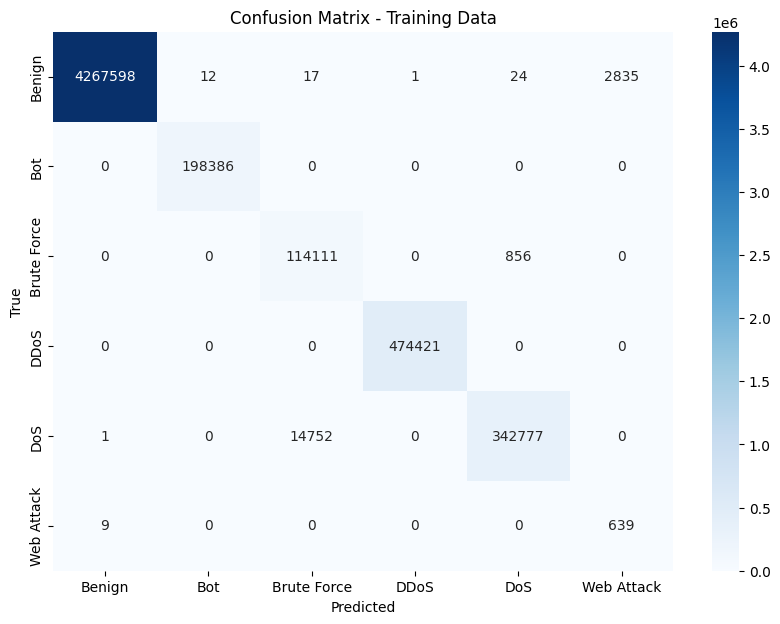

In [37]:
# visualize confusion matrix with class names
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Training Data')
plt.show()

Results are somewhat satisfactory but still below required threshold
before changing model or tuning them lets fix the pipeline

any attribute engineered from timestamp is misleading (because dataset was generated from controlled env)
need to cap the class weights
similar attacks can be grouped (web,dos,bruteforce)
certain features are mathematically equivalent (linearly dependent) Fwd Seg Size Avg (duplicate of Fwd Pkt Len Mean) and Bwd Seg Size Avg (duplicate of Bwd Pkt Len Mean)


In [3]:
# load xgboost model
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("..//output2/downloads/models//xgboost_ids_model2.json")
# print its input feature names
print("Model input feature names:")
print(model.get_booster().feature_names)

Model input feature names:
['Bwd_Pkt_Len_CV', 'Fwd_Pkt_Len_CV', 'Pkt_Len_CV', 'Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Mean', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Active Mean', 'Idle Mean', 'Flow IAT Mean', 'Flow IAT Std', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Down/Up Ratio', 'fwd_bwd_pkt_ratio', 'traffic_symmetry', 'response_ratio', 'bidirectional_active', 'iat_regularity', 'flow_rate', 'timing_asymmetry', 'fwd_bwd_size_diff', 'is_small_packet', 'is_risky_port', 'is_web_traffic', 'port_category', 'anomaly_score', 'Protocol_0.0', 'Protocol_17.0', 'Protocol_6.0']


In [4]:
print(len(model.get_booster().feature_names))

39


In [5]:
# load 1_ohe_feature_encoder.pkl and print its feature names
import joblib
ohe = joblib.load('..//output2//downloads//encoders//1_ohe_feature_encoder.pkl')
print("OneHotEncoder feature names:")
print(ohe.get_feature_names_out())

OneHotEncoder feature names:
['Protocol_0.0' 'Protocol_17.0' 'Protocol_6.0']
